<a href="https://colab.research.google.com/github/nasyafauziah/Indobert_withprepo/blob/main/analisis_sentimen_indobert_stopwords_7epoch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv("/content/data_preprocessing_withstopwordromoval.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   full_text     1997 non-null   object
 1   cleaning      1997 non-null   object
 2   case_folding  1997 non-null   object
 3   normalisasi   1997 non-null   object
 4   text_final    1997 non-null   object
dtypes: object(5)
memory usage: 78.1+ KB


In [2]:
data.head(5)

,full_text,cleaning,case_folding,normalisasi,text_final
0,@PartaiSocmed @Heraloebss Tanpa sebab? Sebabny...,Tanpa sebab Sebabnya seruan bubarkan dpr aga...,tanpa sebab sebabnya seruan bubarkan dpr aga...,tanpa sebab sebabnya seruan bubarkan dpr agar ...,tanpa seruan bubarkan dpr maksulkan gibran tak...
1,Sebab MBG adalah salah satu instrument politik...,Sebab MBG adalah salah satu instrument politik...,sebab mbg adalah salah satu instrument politik...,sebab mbak adalah salah satu instrument politi...,mbak salah instrument politik genk solo sontol...
2,Kl mau fair hrsnya yg menggaungkan hashtag bub...,Kl mau fair hrsnya yg menggaungkan hashtag bub...,kl mau fair hrsnya yg menggaungkan hashtag bub...,kalau mau fair harusnya yang menggaungkan hash...,fair menggaungkan hashtag bubarkan dpr kemarin...
3,@Andria75777 Bubarkan DPR,Bubarkan DPR,bubarkan dpr,bubarkan dpr,bubarkan dpr
4,dia yang hadiri kumpul2 di banyuwangi dgn eks ...,dia yang hadiri kumpul di banyuwangi dgn eks P...,dia yang hadiri kumpul di banyuwangi dgn eks p...,dia yang hadiri kumpul di banyuwangi dengan ek...,hadiri kumpul banyuwangi eks pki


In [3]:
df  = pd.DataFrame(data[['text_final']])
df.head(5)

,text_final
0,tanpa seruan bubarkan dpr maksulkan gibran tak...
1,mbak salah instrument politik genk solo sontol...
2,fair menggaungkan hashtag bubarkan dpr kemarin...
3,bubarkan dpr
4,hadiri kumpul banyuwangi eks pki


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
dtypes: object(1)
memory usage: 15.7+ KB


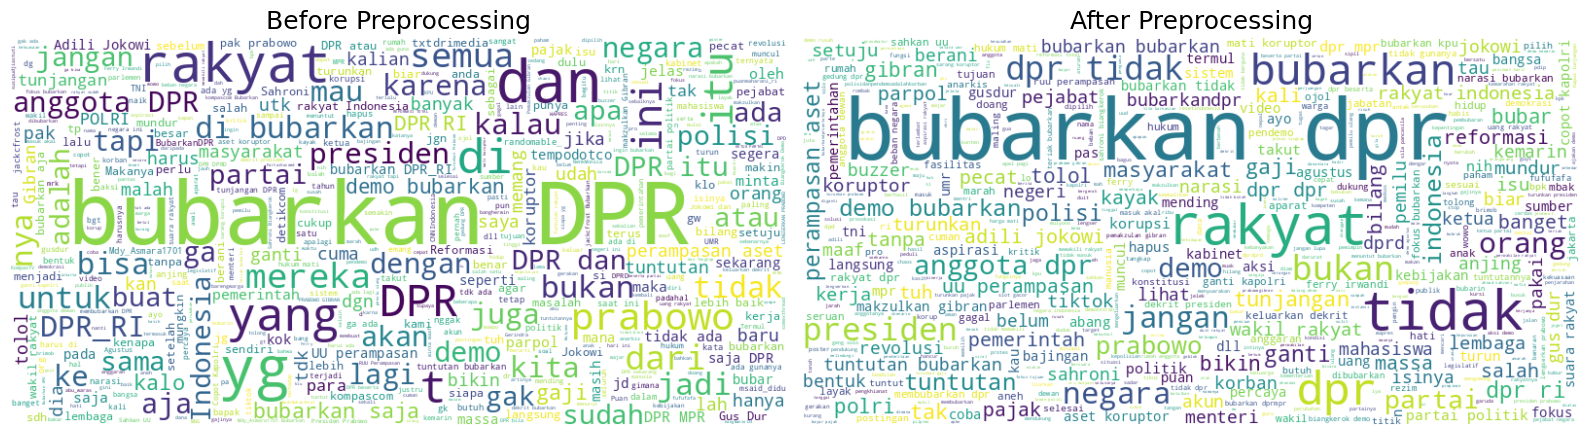

In [5]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','update','apk'])

# WordCloud Before (dari kolom 'Review Text')
text_before = ' '.join(data['full_text'].astype(str).tolist())
wc_before = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400).generate(text_before)

# WordCloud After (dari kolom 'steming_data')
text_after = ' '.join(data['text_final'].astype(str).tolist())
wc_after = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        sentiment = "Negatif" if sentiment_score <= 0 else "Positif"
        return sentiment_score, sentiment
    return 0, "Negatif"

df[['Score', 'Sentiment']] = df['text_final'].apply(lambda x: pd.Series(determine_sentiment(x)))
df.head(5)


,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


/tmp/ipykernel_6763/1334170187.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


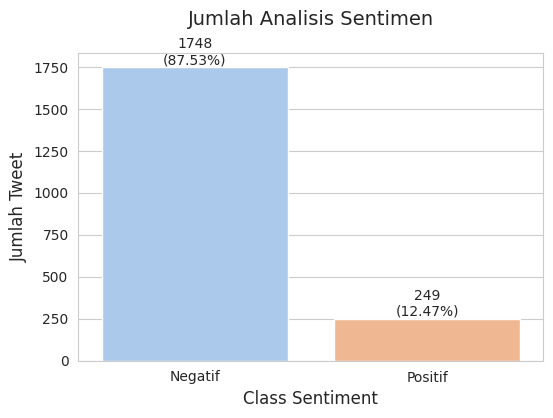

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(df['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [8]:
df.to_csv('Hasil_Labelling_Data.csv',encoding='utf8', index=False)

In [9]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data.csv")
data.head(5)

,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
 1   Score       1997 non-null   int64 
 2   Sentiment   1997 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.9+ KB


In [11]:
data = pd.DataFrame(data[['text_final','Sentiment']])
data.head(25)

,text_final,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,Positif
1,mbak salah instrument politik genk solo sontol...,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,Negatif
3,bubarkan dpr,Negatif
4,hadiri kumpul banyuwangi eks pki,Negatif
5,bubarkan polri pilihan terbaik tak repotrepot ...,Positif
6,gas bubarkan polri tidak repot ganti polri per...,Negatif
7,tidak demo bubarkan dpr kasih gaji umr bubar,Negatif
8,analisa ferry irwandi masuk akal akun provokas...,Negatif
9,lengserkan ya dpr bubarkan bangsa hancur pemil...,Negatif


In [12]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [13]:
!pip install transformers datasets scikit-learn seaborn matplotlib

In [14]:
import os
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset

# Load data
df = pd.read_csv("Hasil_Labelling_Data.csv")

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
 1   Score       1997 non-null   int64 
 2   Sentiment   1997 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.9+ KB


,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


In [15]:
# Encode label jika belum numerik
if df['Sentiment'].dtype == 'object':
    df['Sentiment'] = df['Sentiment'].astype('category').cat.codes

# Split data 80:20 dengan Stratify agar distribusi label seimbang
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

# Tampilkan informasi pembagian
print(f"Jumlah data training: {len(train_df)}")
print(f"Jumlah data testing: {len(test_df)}")
print("\nDistribusi label di data Training:")
print(train_df['Sentiment'].value_counts(normalize=True))
print("\nDistribusi label di data Testing:")
print(test_df['Sentiment'].value_counts(normalize=True))

Jumlah data training: 1597
Jumlah data testing: 400

Distribusi label di data Training:
Sentiment
0    0.875391
1    0.124609
Name: proportion, dtype: float64

Distribusi label di data Testing:
Sentiment
0    0.875
1    0.125
Name: proportion, dtype: float64


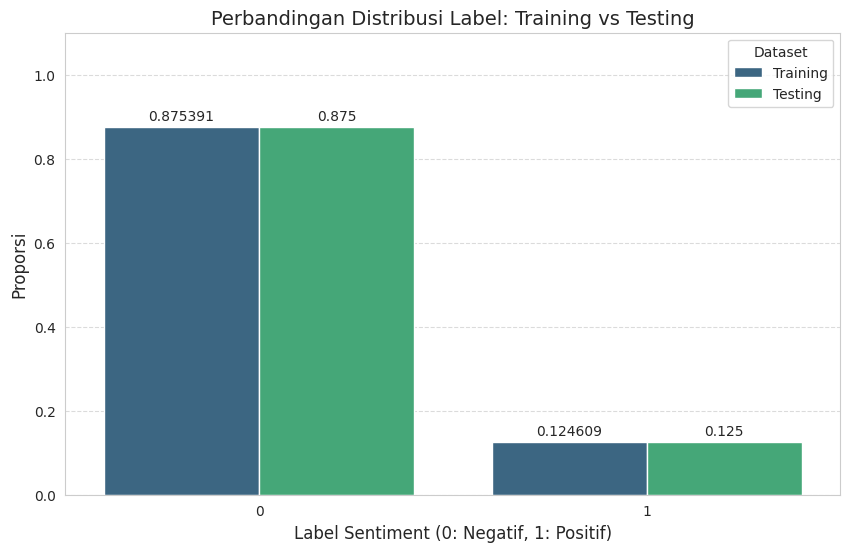

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menghitung distribusi
train_counts = train_df['Sentiment'].value_counts().reset_index()
train_counts['Dataset'] = 'Training'
train_counts['proportion'] = train_counts['count'] / len(train_df)

test_counts = test_df['Sentiment'].value_counts().reset_index()
test_counts['Dataset'] = 'Testing'
test_counts['proportion'] = test_counts['count'] / len(test_df)

# Gabungkan untuk plotting
plot_df = pd.concat([train_counts, test_counts])

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Sentiment', y='proportion', hue='Dataset', data=plot_df, palette='viridis')

# Tambahkan angka jumlah (count) di atas bar
for container in ax.containers:
    # Ambil label count yang sesuai dari data
    labels = plot_df[plot_df['Dataset'] == container.get_label()]['count']
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Perbandingan Distribusi Label: Training vs Testing', fontsize=14)
plt.xlabel('Label Sentiment (0: Negatif, 1: Positif)', fontsize=12)
plt.ylabel('Proporsi', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
# Inisialisasi Tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(example):
    # Menambahkan padding='max_length' agar semua urutan panjangnya sama
    return tokenizer(example["text_final"], truncation=True, padding='max_length', max_length=128)

# Konversi pandas ke HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Lakukan Tokenisasi
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Ganti nama 'Sentiment' menjadi 'labels' dan hapus kolom yang tidak diperlukan oleh model
train_dataset = train_dataset.rename_column("Sentiment", "labels")
test_dataset = test_dataset.rename_column("Sentiment", "labels")

# Kolom yang harus dibuang agar model tidak error
columns_to_remove = ['text_final', 'Score', '__index_level_0__']
train_dataset = train_dataset.remove_columns([col for col in columns_to_remove if col in train_dataset.column_names])
test_dataset = test_dataset.remove_columns([col for col in columns_to_remove if col in test_dataset.column_names])

# Set format dataset untuk PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Tokenisasi selesai. Kolom dataset sekarang:", train_dataset.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/1597 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenisasi selesai. Kolom dataset sekarang: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


Panjang rata-rata: 19.28
Panjang maksimal: 60
Persentase teks <= 128 token: 100.00%


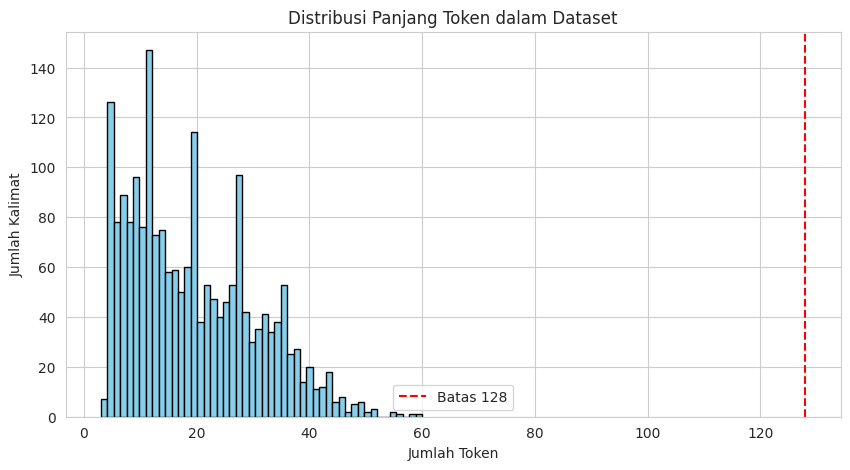

In [20]:
import matplotlib.pyplot as plt

# Hitung jumlah token untuk setiap kalimat di text_final
df['text_len'] = df['text_final'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=True)))

print(f"Panjang rata-rata: {df['text_len'].mean():.2f}")
print(f"Panjang maksimal: {df['text_len'].max()}")
print(f"Persentase teks <= 128 token: {(df['text_len'] <= 128).mean() * 100:.2f}%")

# Visualisasi distribusi
plt.figure(figsize=(10, 5))
plt.hist(df['text_len'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribusi Panjang Token dalam Dataset')
plt.xlabel('Jumlah Token')
plt.ylabel('Jumlah Kalimat')
plt.axvline(128, color='red', linestyle='--', label='Batas 128')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Inisialisasi Model
model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=2)

# Training Arguments dengan 7 Epoch
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Inisialisasi Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Konfigurasi siap untuk 7 epoch. Gunakan 'trainer.train()' untuk memulai.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Konfigurasi siap untuk 7 epoch. Gunakan 'trainer.train()' untuk memulai.


In [ ]:
# Train
trainer.train()

#  Evaluate
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.352821,0.877500,0.075472,0.666667,0.040000
2,No log,0.354721,0.882500,0.298507,0.588235,0.200000
3,No log,0.507868,0.852500,0.337079,0.384615,0.300000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Menampilkan Classification Report
print("Classification Report:")
print(classification_report(true, preds, target_names=['Negatif', 'Positif']))

# Membuat Confusion Matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()